In [21]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import pickle
import json
import os
from datetime import datetime

# Load all CSVs
orders    = pd.read_csv('../data/olist_orders_dataset.csv')
items     = pd.read_csv('../data/olist_order_items_dataset.csv')
payments  = pd.read_csv('../data/olist_order_payments_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
products  = pd.read_csv('../data/olist_products_dataset.csv')
sellers   = pd.read_csv('../data/olist_sellers_dataset.csv')
reviews   = pd.read_csv('../data/olist_order_reviews_dataset.csv')

print("All CSVs loaded!")

All CSVs loaded!


In [22]:
# Filter delivered orders only
orders = orders[orders['order_status'] == 'delivered']

# Merge
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(items, on='order_id', how='left')
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

print(f"Merged shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Merged shape: (115723, 23)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'review_score']


In [23]:
# Parse dates
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Aggregate to customer level
customer_df = df.groupby('customer_unique_id').agg(
    recency_days          = ('order_purchase_timestamp',
                             lambda x: (snapshot_date - x.max()).days),
    frequency             = ('order_id', 'nunique'),
    total_revenue         = ('payment_value', 'sum'),
    avg_order_value       = ('payment_value', 'mean'),
    max_order_value       = ('payment_value', 'max'),
    min_order_value       = ('payment_value', 'min'),
    total_items           = ('order_item_id', 'count'),
    avg_item_price        = ('price', 'mean'),
    total_freight         = ('freight_value', 'sum'),
    freight_ratio         = ('freight_value', lambda x:
                             x.sum() / df.loc[x.index, 'price'].sum()
                             if df.loc[x.index, 'price'].sum() > 0 else 0),
    unique_products       = ('product_id', 'nunique'),
    unique_sellers        = ('seller_id', 'nunique'),
    avg_installments      = ('payment_installments', 'mean'),
    avg_review_score      = ('review_score', 'mean'),
    first_order_date      = ('order_purchase_timestamp', 'min'),
    last_order_date       = ('order_purchase_timestamp', 'max'),
    customer_state        = ('customer_state', 'first'),
).reset_index()

customer_df['customer_lifetime_days'] = (
    customer_df['last_order_date'] - customer_df['first_order_date']
).dt.days

customer_df['orders_per_month'] = (
    customer_df['frequency'] /
    (customer_df['customer_lifetime_days'] / 30).clip(lower=1)
)

customer_df['LTV'] = customer_df['total_revenue']

print(f"Customer dataset shape: {customer_df.shape}")
print(f"\nLTV stats:\n{customer_df['LTV'].describe()}")

Customer dataset shape: (93358, 21)

LTV stats:
count     93358.000000
mean        212.964557
std         646.223866
min           0.000000
25%          63.830000
50%         113.140000
75%         202.637500
max      109312.640000
Name: LTV, dtype: float64


In [24]:
# Drop nulls
customer_df = customer_df.dropna(subset=['avg_order_value'])
customer_df['avg_review_score'] = customer_df['avg_review_score'].fillna(
    customer_df['avg_review_score'].median()
)

# Cap LTV at 99th percentile
ltv_cap = customer_df['LTV'].quantile(0.99)
customer_df['LTV'] = customer_df['LTV'].clip(upper=ltv_cap)
print(f"LTV capped at: ${ltv_cap:.2f}")

# Log transform
customer_df['LTV_log'] = np.log1p(customer_df['LTV'])

# Encode state
le = LabelEncoder()
customer_df['state_encoded'] = le.fit_transform(customer_df['customer_state'])

print(f"Clean dataset shape: {customer_df.shape}")

LTV capped at: $1684.28
Clean dataset shape: (93357, 23)


In [25]:
# Leakage-free features
# Excluded: avg_order_value, max_order_value, min_order_value, total_freight
# These are derived from payment_value which directly builds LTV

feature_cols = [
    'recency_days',
    'frequency',
    'total_items',
    'avg_item_price',
    'freight_ratio',
    'unique_products',
    'unique_sellers',
    'avg_installments',
    'avg_review_score',
    'customer_lifetime_days',
    'orders_per_month',
    'state_encoded'
]

X = customer_df[feature_cols]
y = customer_df['LTV_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Production Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)

# Evaluate
y_pred      = pipeline.predict(X_test)
y_pred_orig = np.expm1(y_pred)
y_test_orig = np.expm1(y_test)

r2        = r2_score(y_test, y_pred)
rmse_log  = np.sqrt(mean_squared_error(y_test, y_pred))
mae_log   = mean_absolute_error(y_test, y_pred)
rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae_orig  = mean_absolute_error(y_test_orig, y_pred_orig)

print(f"\n--- Leakage-Free Model Performance ---")
print(f"R²:               {r2:.4f}")
print(f"RMSE (log scale): {rmse_log:.4f}")
print(f"MAE  (log scale): {mae_log:.4f}")
print(f"RMSE ($ actual):  ${rmse_orig:.2f}")
print(f"MAE  ($ actual):  ${mae_orig:.2f}")

# MLOps: Save model + update registry
os.makedirs('../model', exist_ok=True)
version = datetime.now().strftime("v%Y%m%d_%H%M%S")

with open(f'../model/ltv_pipeline_{version}.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

with open('../model/latest_model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

registry_path = '../model/model_registry.json'
registry = []
if os.path.exists(registry_path):
    with open(registry_path, 'r') as f:
        registry = json.load(f)

registry.append({
    'version':      version,
    'trained_at':   datetime.now().isoformat(),
    'model_type':   'XGBRegressor',
    'features':     feature_cols,
    'n_train':      len(X_train),
    'n_test':       len(X_test),
    'r2':           round(r2, 4),
    'rmse_log':     round(rmse_log, 4),
    'mae_log':      round(mae_log, 4),
    'rmse_dollars': round(rmse_orig, 2),
    'mae_dollars':  round(mae_orig, 2),
    'model_path':   f'../model/ltv_pipeline_{version}.pkl'
})

with open(registry_path, 'w') as f:
    json.dump(registry, f, indent=2)

print(f"\nModel version: {version}")
print(f"Registry updated!")

Train: (74685, 12) | Test: (18672, 12)

--- Leakage-Free Model Performance ---
R²:               0.9471
RMSE (log scale): 0.2045
MAE  (log scale): 0.0720
RMSE ($ actual):  $91.39
MAE  ($ actual):  $23.74

Model version: v20260224_152944
Registry updated!


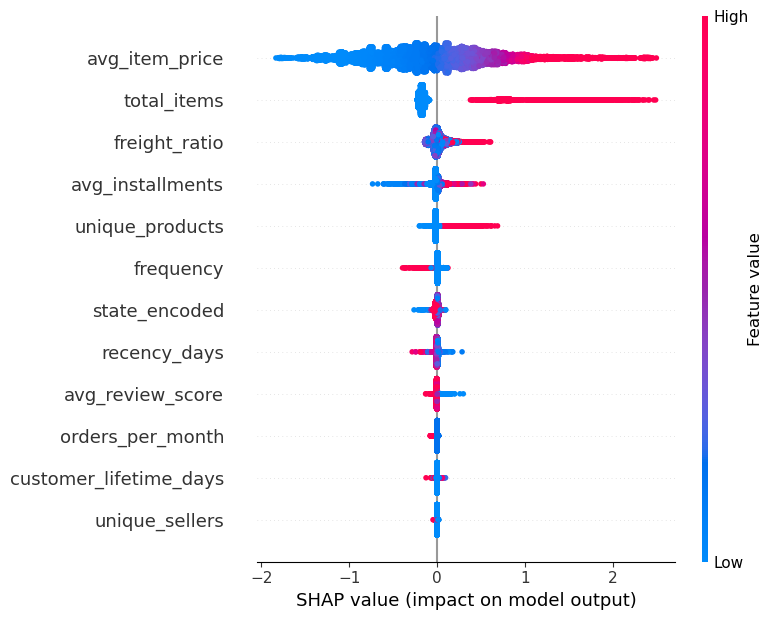

SHAP explainer saved!


In [28]:
import shap

# ── SHAP on the XGBoost step inside the pipeline ──
xgb_model = pipeline.named_steps['model']
scaler = pipeline.named_steps['scaler']

# Transform test data through scaler first
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled_df)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test_scaled_df, feature_names=feature_cols)

# Save explainer for Streamlit app
with open('../model/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("SHAP explainer saved!")

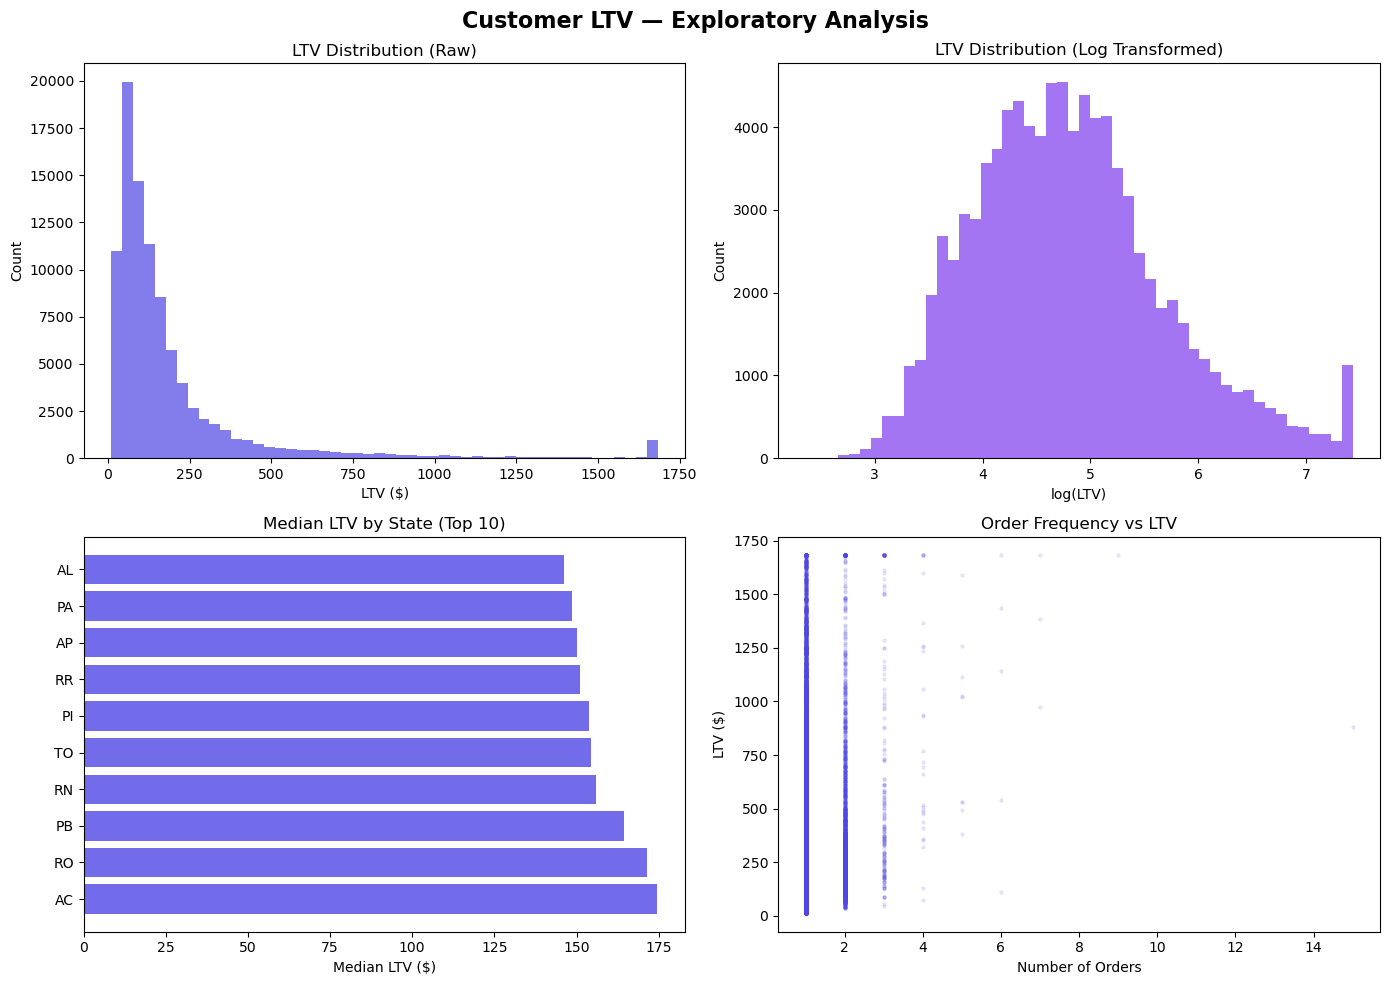

EDA plots saved!


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer LTV — Exploratory Analysis', fontsize=16, fontweight='bold')

# 1. LTV distribution before log transform
axes[0,0].hist(customer_df['LTV'], bins=50, color='#4f46e5', alpha=0.7, edgecolor='none')
axes[0,0].set_title('LTV Distribution (Raw)')
axes[0,0].set_xlabel('LTV ($)')
axes[0,0].set_ylabel('Count')

# 2. LTV distribution after log transform
axes[0,1].hist(customer_df['LTV_log'], bins=50, color='#7c3aed', alpha=0.7, edgecolor='none')
axes[0,1].set_title('LTV Distribution (Log Transformed)')
axes[0,1].set_xlabel('log(LTV)')
axes[0,1].set_ylabel('Count')

# 3. LTV by state (top 10)
top_states = customer_df.groupby('customer_state')['LTV'].median().nlargest(10)
axes[1,0].barh(top_states.index, top_states.values, color='#4f46e5', alpha=0.8)
axes[1,0].set_title('Median LTV by State (Top 10)')
axes[1,0].set_xlabel('Median LTV ($)')

# 4. Frequency vs LTV
axes[1,1].scatter(customer_df['frequency'], customer_df['LTV'],
                  alpha=0.1, color='#4f46e5', s=5)
axes[1,1].set_title('Order Frequency vs LTV')
axes[1,1].set_xlabel('Number of Orders')
axes[1,1].set_ylabel('LTV ($)')

plt.tight_layout()
plt.savefig('../model/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

In [30]:
# ── Data Drift Baseline ──
drift_baseline = {}
for col in feature_cols:
    drift_baseline[col] = {
        'mean': float(X_train[col].mean()),
        'std':  float(X_train[col].std()),
        'min':  float(X_train[col].min()),
        'max':  float(X_train[col].max()),
        'p25':  float(X_train[col].quantile(0.25)),
        'p50':  float(X_train[col].quantile(0.50)),
        'p75':  float(X_train[col].quantile(0.75)),
    }

with open('../model/drift_baseline.json', 'w') as f:
    json.dump(drift_baseline, f, indent=2)

# ── Save feature cols for app ──
with open('../model/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

# ── Save processed customer data for batch predictions ──
customer_df[feature_cols + ['LTV', 'LTV_log', 'customer_unique_id']].to_csv(
    '../data/processed_customers.csv', index=False
)

# ── Save label encoder for state ──
with open('../model/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Saved:")
print("  ✓ drift_baseline.json")
print("  ✓ feature_cols.json")
print("  ✓ processed_customers.csv")
print("  ✓ label_encoder.pkl")
print("\nNotebook complete! Ready to build Streamlit app.")

Saved:
  ✓ drift_baseline.json
  ✓ feature_cols.json
  ✓ processed_customers.csv
  ✓ label_encoder.pkl

Notebook complete! Ready to build Streamlit app.
